# Part 4 — MDPs and the Bellman equations: when today's choice changes tomorrow

In Parts 2–3 every week was a fresh start: open Monday, expire Friday, nothing carries over.
Real trading isn't like that:

* You hold a **2-week or 45-DTE** option. Next Monday you're still *in* the position.
* **Closing early costs money** (commissions plus the bid-ask spread, again).
* Switching from a short straddle to a long straddle costs **two** sets of fees.
* A drawdown this month may **cut next month's risk budget**.

In all of these, today's action changes tomorrow's **state**. That makes the problem a
**Markov Decision Process (MDP)**, and a greedy "best this week" rule is no longer optimal.

**Analogy: the gym membership.** Joining costs a \$60 fee. If you judge only *this week*, the fee
is never worth it: one workout doesn't justify \$60. But you'll go for months, so the fee is
spread over many weeks. A short-sighted agent never joins, and a far-sighted one does. Opening an
options position with costs is exactly this.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import optrl
from optrl import metrics as M
M.set_style()

---
## 4.1 The Markov property

**Plain English.** A state is *Markov* if it contains everything you need to predict the future.
Once you know the current state, **how you got there doesn't matter**.

**Analogy.** A chess position is Markov: the board tells you everything, and the move history
doesn't change which moves are good. A poker hand *isn't*, if you ignore the betting so far,
because the betting tells you something the cards on the table don't.

**Options example.** Suppose the state is only "VIX = 16". Is that Markov? No. VIX 16 *falling
from 30* (post-crisis calm returning) is a different situation from VIX 16 *rising from 11*
(stress building). Adding term structure, trend and your **open position** gets you closer.

**Formally:** $P(s_{t+1} \mid s_t, a_t) = P(s_{t+1} \mid s_t, a_t, s_{t-1}, a_{t-1}, \dots)$.

### 🛠 Exercise 4.1: test Markov-ness empirically
The simulator's hidden **regime** is Markov by construction. The observable **VIX bucket**
(low < 15, mid 15–22, high > 22) probably isn't. Use the value `"range"` for the regime and
`"low"` for the VIX bucket. For each, compare
P(next = X | current = X) with P(next = X | current = X **and** previous = X).
If adding the previous value changes the probability a lot, the state isn't Markov.

*Expected:* for the regime, the two probabilities are almost equal. For the VIX bucket they
differ more. The history carries extra information, so VIX alone is not a Markov state.

In [2]:
market = optrl.load_default_market()
df = market.df

def markov_check(series, value):
    s = pd.Series(series).reset_index(drop=True)
    # TODO: p1 = P(s[t+1]==value | s[t]==value) ; p2 = P(s[t+1]==value | s[t]==value & s[t-1]==value)
    return None

**Solution**

In [3]:
def markov_check(series, value):
    s = pd.Series(np.asarray(series))
    cur, nxt, prev = s.iloc[1:-1].values, s.iloc[2:].values, s.iloc[:-2].values
    p1 = (nxt[cur == value] == value).mean()
    p2 = (nxt[(cur == value) & (prev == value)] == value).mean()
    fresh = (cur == value) & (prev != value)
    p3 = (nxt[fresh] == value).mean()
    return p1, p2, p3, fresh.sum()

vix_bucket = pd.cut(df.vix, [0, 15, 22, 100], labels=["low", "mid", "high"]).astype(str)
for name, series, val in [("regime", df.regime_name, "range"), ("VIX bucket", vix_bucket, "low")]:
    p1, p2, p3, nf = markov_check(series, val)
    print(f"{name:10s} P(stay {val}) = {p1:.3f} | if also {val} yesterday: {p2:.3f} | if it just arrived: {p3:.3f} (n={nf})")

regime     P(stay range) = 0.975 | if also range yesterday: 0.975 | if it just arrived: 0.976 (n=41)
VIX bucket P(stay low) = 0.825 | if also low yesterday: 0.861 | if it just arrived: 0.657 (n=277)


For the regime, "just arrived" and "been here a while" give the same persistence (≈ 0.975). For
the VIX bucket, a *fresh* dip into low VIX is much less sticky (≈ 0.66) than an established
one (≈ 0.86). History matters, so VIX alone
isn't Markov. **Practical rule:** add the features that make history irrelevant (trend, term
structure, your position, days held). You'll never get a perfectly Markov state from market
data, but closer is better.

---
## 4.2 The toy MDP: "hold, switch or sit out"

A small problem we can solve exactly, built to capture what matters in the real one.

* **Market regime** (hidden in real life, visible here): `calm` or `stormy`.
  Calm stays calm with probability 0.9. Stormy stays stormy with probability 0.7.
* **Your position**: `flat`, `short_vol` (a premium seller like the iron condor) or `long_vol`
  (a long straddle).
* **State** = (regime, position) → 2 × 3 = **6 states**.
* **Action** = the position you want for the coming week: flat / short_vol / long_vol.
* **Weekly P&L** of holding each position, depending on **next week's** regime:

| position | calm week | stormy week |
|---|---|---|
| flat | 0 | 0 |
| short_vol | **+\$90** | **−\$300** |
| long_vol | −\$80 | **+\$250** |

* **Transaction cost**: \$60 to open a position and \$60 to close one. Switching from short_vol
  to long_vol costs \$120.
* Reward = P&L − costs.

Formally an MDP is a tuple $(S, A, P, R, \gamma)$:
states, actions, transition probabilities $P(s'|s,a)$, rewards $R(s,a,s')$, and the discount.

In [4]:
REG = ["calm", "stormy"]; POS = ["flat", "short_vol", "long_vol"]
P_REG = np.array([[0.9, 0.1],           # from calm   → calm, stormy
                  [0.3, 0.7]])          # from stormy → calm, stormy
PNL = np.array([[0, 0],                 # flat
                [90, -300],             # short_vol   (calm, stormy)
                [-80, 250]])            # long_vol
COST = 60
STATES = [(r, p) for r in range(2) for p in range(3)]           # index = r*3 + p

def reward(s, a, r_next):
    r, p = STATES[s]
    cost = 0 if a == p else COST * ((p != 0) + (a != 0))         # close old (if any) + open new (if any)
    return PNL[a, r_next] - cost

def next_state(a, r_next):
    return r_next * 3 + a                                        # the new position is the action

---
## 4.3 The Bellman expectation equation: evaluating a policy

In Part 1 you saw $G_t = r_{t+1} + \gamma G_{t+1}$. Take expectations and you get the
**Bellman expectation equation**. The value of a state is the expected immediate reward plus
the discounted value of wherever you land:

$$ V^\pi(s) = \sum_{s'} P(s' \mid s, \pi(s))\,\big[\,R(s,\pi(s),s') + \gamma\,V^\pi(s')\,\big] $$

*In words:* "how good is it to be here" = "what I expect to earn this week" + γ × "how good
the place I end up is, on average".

**Worked example.** Policy π = "always short_vol". State = (calm, short_vol), γ = 0.9, and
suppose we already know V(calm, short_vol) = 420 and V(stormy, short_vol) = 50.
* 90% chance next week is calm: reward +90 (no cost, we just hold) → 90 + 0.9·420 = 468
* 10% chance stormy: reward −300 → −300 + 0.9·50 = −255
* V = 0.9·468 + 0.1·(−255) = 421.2 − 25.5 = **395.7**

That doesn't equal the 420 we assumed, so 420 wasn't the true value. **Iterative policy
evaluation** repeats this update for every state until the numbers stop changing.

In [5]:
def evaluate_policy(policy, gamma=0.9, tol=1e-8):
    """policy: array of 6 actions. Returns V (6,) by repeatedly applying Bellman expectation."""
    V = np.zeros(6)
    while True:
        V_new = np.zeros(6)
        for s in range(6):
            r = STATES[s][0]; a = policy[s]
            V_new[s] = sum(P_REG[r, r2] * (reward(s, a, r2) + gamma * V[next_state(a, r2)]) for r2 in range(2))
        if np.abs(V_new - V).max() < tol:
            return V_new
        V = V_new

def show(V, title):
    return pd.DataFrame(np.asarray(V).reshape(2, 3), index=REG, columns=POS).round(1).rename_axis(title)

always_short = [1] * 6
show(evaluate_policy(always_short), "V: always short_vol")

,flat,short_vol,long_vol
V: always short_vol,,,
calm,-7.8,52.2,-67.8
stormy,-516.5,-456.5,-576.5


### 🛠 Exercise 4.3
Evaluate two more policies with γ = 0.9:
(a) always `flat`, and (b) a "regime-follower": short_vol when calm, long_vol when stormy.

*Expected:* (a) all zeros. (b) higher than "always short_vol" in every state, because it
avoids the stormy losses, even after paying switching costs.

In [6]:
# TODO

**Solution**

In [7]:
follower = [1 if STATES[s][0] == 0 else 2 for s in range(6)]
display(show(evaluate_policy([0] * 6), "V: always flat"))
display(show(evaluate_policy(follower), "V: regime follower"))

,flat,short_vol,long_vol
V: always flat,,,
calm,0.0,-60.0,-60.0
stormy,0.0,-60.0,-60.0


,flat,short_vol,long_vol
V: regime follower,,,
calm,495.4,555.4,435.4
stormy,665.8,605.8,725.8


---
## 4.4 The Bellman optimality equation and value iteration

We don't just want to *evaluate* a policy. We want the **best** one. The optimal value obeys
the **Bellman optimality equation**. It's the same as before, but the agent picks the best
action instead of following a fixed π:

$$ Q^*(s,a) = \sum_{s'} P(s'|s,a)\,\big[R(s,a,s') + \gamma \max_{a'} Q^*(s',a')\big], \qquad V^*(s) = \max_a Q^*(s,a) $$

*In words:* the value of doing *a* now = expected reward + γ × the value of acting optimally
from wherever you land.

**Value iteration** turns that equation into an algorithm: start with V = 0, apply the
right-hand side to get new values, repeat until convergence. It's guaranteed to converge for
γ < 1, because each sweep shrinks the error by a factor of γ.

**Worked example (first sweep, γ = 0.9, from V = 0).** State (calm, flat), action short_vol:
0.9·(90 − 60) + 0.1·(−300 − 60) = 27 − 36 = **−9**. Action flat: **0**. Action long_vol:
0.9·(−80 − 60) + 0.1·(250 − 60) = −126 + 19 = **−107**. After one sweep (which is a **γ = 0**,
one-week view), "flat" wins in calm. Opening costs more than one week of short vol earns.

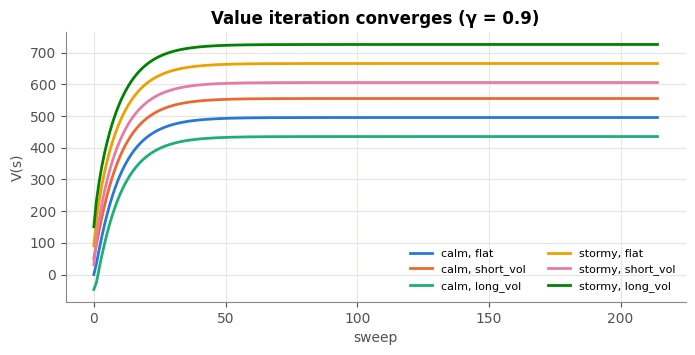

converged in 215 sweeps


In [8]:
def value_iteration(gamma=0.9, tol=1e-8, history=False):
    V = np.zeros(6); hist = []
    while True:
        Q = np.zeros((6, 3))
        for s in range(6):
            r = STATES[s][0]
            for a in range(3):
                Q[s, a] = sum(P_REG[r, r2] * (reward(s, a, r2) + gamma * V[next_state(a, r2)]) for r2 in range(2))
        V_new = Q.max(1); hist.append(V_new.copy())
        if np.abs(V_new - V).max() < tol:
            return (Q, np.array(hist)) if history else Q
        V = V_new

Q9, hist = value_iteration(0.9, history=True)
fig, ax = plt.subplots(figsize=(8, 3.5))
for s in range(6):
    ax.plot(hist[:, s], label=f"{REG[STATES[s][0]]}, {POS[STATES[s][1]]}", color=M.PALETTE[s])
ax.set_xlabel("sweep"); ax.set_ylabel("V(s)"); ax.set_title("Value iteration converges (γ = 0.9)")
ax.legend(fontsize=8, ncol=2); plt.show()
print(f"converged in {len(hist)} sweeps")

### Myopic (bandit) vs far-sighted (MDP) policies

In [9]:
def policy_table(Q):
    return pd.DataFrame(np.array(POS)[Q.argmax(1)].reshape(2, 3), index=[f"regime={r}" for r in REG],
                        columns=[f"holding {p}" for p in POS])

Q0 = value_iteration(0.0)
print("γ = 0 (myopic, 'best this week' = a bandit):"); display(policy_table(Q0))
print("γ = 0.9 (far-sighted):"); display(policy_table(Q9))
print("Q-values in (calm, flat):  γ=0 →", dict(zip(POS, Q0[0].round(1))), "  γ=0.9 →", dict(zip(POS, Q9[0].round(1))))

γ = 0 (myopic, 'best this week' = a bandit):


,holding flat,holding short_vol,holding long_vol
regime=calm,flat,short_vol,long_vol
regime=stormy,long_vol,long_vol,long_vol


γ = 0.9 (far-sighted):


,holding flat,holding short_vol,holding long_vol
regime=calm,short_vol,short_vol,short_vol
regime=stormy,long_vol,long_vol,long_vol


Q-values in (calm, flat):  γ=0 → {'flat': np.float64(0.0), 'short_vol': np.float64(-9.0), 'long_vol': np.float64(-107.0)}   γ=0.9 → {'flat': np.float64(461.2), 'short_vol': np.float64(495.4), 'long_vol': np.float64(311.0)}


**Two decisions change when the agent looks ahead:**

1. **(calm, flat)**: the myopic agent stays flat, because one week of short vol is worth +\$51 in
   expectation (0.9·90 − 0.1·300, storm risk included), which doesn't cover the \$60 open cost. The far-sighted agent **opens
   short_vol**, because it expects to hold for many calm weeks and the fee is amortised. It's
   the gym membership.
2. **(calm, long_vol)**: the storm is over and you're holding a long straddle. Myopic: "switching
   costs \$120 this week, so keep holding" (a sunk-cost trap). Far-sighted: "pay \$120 once and
   collect premium for the coming calm weeks" → **switch to short_vol**.

This is the heart of it. **With carry-over and transaction costs, the best action depends on
what you'll do next, not just on this week's expected P&L.** A bandit can't represent that.

### Verify by simulation
Values from equations are nice, but traders trust P&L. Simulate 20,000 weeks with each policy.

In [10]:
def simulate(policy_Q, n=20_000, seed=0):
    rng = np.random.default_rng(seed)
    r, p, total = 0, 0, 0.0
    for _ in range(n):
        s = r * 3 + p
        a = int(policy_Q[s].argmax())
        r2 = rng.choice(2, p=P_REG[r])
        total += reward(s, a, r2)
        r, p = r2, a
    return total / n

for g in [0.0, 0.5, 0.9, 0.99]:
    print(f"policy optimal for γ={g:<4} → average P&L ${simulate(value_iteration(g)):6.1f}/week")

policy optimal for γ=0.0  → average P&L $   0.7/week
policy optimal for γ=0.5  → average P&L $  57.2/week


policy optimal for γ=0.9  → average P&L $  57.2/week


policy optimal for γ=0.99 → average P&L $  57.2/week


The far-sighted policies earn more **per week, undiscounted**, which is what you actually get
paid. γ is a modelling knob for "how far ahead should decisions look", and with multi-week
holding periods you need it clearly above 0.

### 🛠 Exercise 4.4a: when is a bandit enough?
Set `COST = 0` and recompute the γ = 0 and γ = 0.9 policy tables. *Expected:* they become
**identical**. With no transaction costs, your position doesn't constrain the future (you can
switch freely), so the best action each week is just the best one-week bet. The MDP collapses
into a contextual bandit. Remember to set `COST = 60` again afterwards.

In [11]:
# TODO

**Solution**

In [12]:
COST = 0
print("γ=0:"); display(policy_table(value_iteration(0.0)))
print("γ=0.9:"); display(policy_table(value_iteration(0.9)))
COST = 60

γ=0:


,holding flat,holding short_vol,holding long_vol
regime=calm,short_vol,short_vol,short_vol
regime=stormy,long_vol,long_vol,long_vol


γ=0.9:


,holding flat,holding short_vol,holding long_vol
regime=calm,short_vol,short_vol,short_vol
regime=stormy,long_vol,long_vol,long_vol


### 🛠 Exercise 4.4b: how much cost makes the agent stop trading?
Sweep `COST` from 0 to 500 in steps of 50. For each, compute the γ = 0.9 policy and its
simulated average weekly P&L. Plot P&L vs cost and watch how the policy changes.

*Expected:* at first the policy stays the same and P&L falls steadily (you pay more for the
same trades). Around \$200 the policy **changes character**. It stops opening from flat and
starts *holding whatever it has*: a long straddle is kept through calm weeks because getting
out costs too much. At high costs the agent is **frozen**, and inertia becomes optimal. This is
why modelling costs realistically matters so much for strategy selection.

In [13]:
# TODO

**Solution**

 cost    pnl                                                             policy
    0 74.960 short_vol | short_vol | short_vol | long_vol | long_vol | long_vol
   50 60.125 short_vol | short_vol | short_vol | long_vol | long_vol | long_vol
  100 45.290 short_vol | short_vol | short_vol | long_vol | long_vol | long_vol
  150 30.455 short_vol | short_vol | short_vol | long_vol | long_vol | long_vol
  200 -0.838       flat | short_vol | long_vol | long_vol | long_vol | long_vol
  250 -0.843       flat | short_vol | long_vol | long_vol | long_vol | long_vol
  300 -0.848       flat | short_vol | long_vol | long_vol | long_vol | long_vol
  350  0.000               flat | short_vol | long_vol | flat | flat | long_vol
  400  0.000               flat | short_vol | long_vol | flat | flat | long_vol
  450  0.000               flat | short_vol | long_vol | flat | flat | long_vol
  500  0.000          flat | short_vol | long_vol | flat | short_vol | long_vol


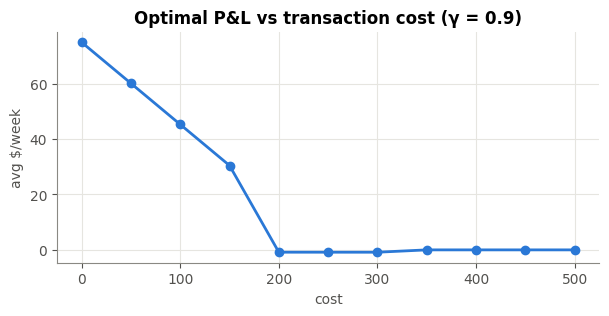

In [14]:
rows = []
for c in range(0, 501, 50):
    COST = c
    Q = value_iteration(0.9)
    rows.append({"cost": c, "pnl": simulate(Q, n=10_000), "policy": " | ".join(np.array(POS)[Q.argmax(1)])})
COST = 60
res = pd.DataFrame(rows); print(res.to_string(index=False))
ax = res.plot(x="cost", y="pnl", marker="o", legend=False, figsize=(7, 3), color=M.PALETTE[0])
ax.set_ylabel("avg $/week"); ax.set_title("Optimal P&L vs transaction cost (γ = 0.9)"); plt.show()

---
## 4.5 When does strategy selection need an MDP? A checklist

| Situation in your trading | Bandit enough? | Why |
|---|---|---|
| Weekly options, open Monday, expire Friday, flat every weekend | ✅ contextual bandit | nothing carries over |
| Options held longer than one decision period (2-week, 30–45 DTE) | ❌ MDP | the open position is part of the state |
| Closing or switching early costs money | ❌ MDP | today's choice changes tomorrow's costs |
| Rolling or adjusting a position (roll the tested side) | ❌ MDP | the action depends on the current position |
| Risk budget depends on recent P&L / drawdown limits | ❌ MDP | past rewards change future options |
| Margin used by open trades limits new trades | ❌ MDP | capacity carries over |
| Your trades move the market (large size) | ❌ MDP | your action changes the next state |

**Honest advice.** Start with the simplest thing that captures your reality. If your
strategies are truly weekly with no carry-over, a contextual bandit (Part 3) is not a
compromise, it's the *correct* model, and it's much easier to train and validate. Move to an
MDP when the checklist says so.

## 4.6 The catch: we cheated
Value iteration needed $P(s'|s,a)$ and $R$, a full model of the market. In reality you don't
have one. The regimes are hidden, and the transition probabilities are unknown and drift over
time. **Part 5 learns Q\* directly from experience, with no model**: Q-learning and SARSA.

## Recap
* **MDP** = states, actions, transitions, rewards, discount. Needed when actions affect future states.
* **Markov property**: the state must summarise the relevant history. Include your position!
* **Bellman expectation**: V(s) = E[r + γ V(s')] evaluates a policy.
  **Bellman optimality**: Q\*(s,a) = E[r + γ max Q\*(s',·)] defines the best one.
* **Value iteration** solves it when the model is known.
* With transaction costs and carry-over, **far-sighted beats myopic**: amortise entry costs,
  and don't fall for sunk costs.